# Import Libraries/Datasets


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import os
import matplotlib.pyplot as plt
import PIL
from PIL import Image, UnidentifiedImageError
import seaborn as sns
import plotly
import plotly.graph_objs as go
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from plotly.offline import iplot, init_notebook_mode
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
base_path = "/content/drive/MyDrive/Diabetic_Retinopathy/archive/colored_images"
os.listdir(base_path)

['Mild', 'No_DR', 'Moderate', 'Proliferate_DR', 'Severe']

In [4]:
os.listdir(os.path.join(base_path, "Mild"))

['0124dffecf29.png',
 '0ad7f631dedb.png',
 '07a1c7073982.png',
 '0dc031c94225.png',
 '01b3aed3ed4c.png',
 '09935d72892b.png',
 '0a3202889f4d.png',
 '05a5183c92d0.png',
 '04ac765f91a1.png',
 '07929d32b5b3.png',
 '0684311afdfc.png',
 '03e25101e8e8.png',
 '0a61bddab956.png',
 '0024cdab0c1e.png',
 '086d41d17da8.png',
 '06b71823f9cd.png',
 '059bc89df7f4.png',
 '00cb6555d108.png',
 '0d310aba6373.png',
 '0369f3efe69b.png',
 '0fb1053285cf.png',
 '10f36b0239fb.png',
 '1bb0ddfe753a.png',
 '1a03a7970337.png',
 '101b9ebfc720.png',
 '194814669fee.png',
 '19722bff5a09.png',
 '12e3f5f2cb17.png',
 '19e350c7c83c.png',
 '1b329a127307.png',
 '1116271db4ea.png',
 '17eff993386f.png',
 '0dce95217626.png',
 '0eb52045349f.png',
 '18b06f56ab27.png',
 '111898ab463d.png',
 '107aea0d9289.png',
 '13ab8db8c700.png',
 '12ce6a1a1f31.png',
 '172df1330a60.png',
 '15cc2aef772a.png',
 '29b52f64d2db.png',
 '0f495d87656a.png',
 '248139c423c4.png',
 '1d11794057ff.png',
 '2a08ed6bbcbc.png',
 '2994f17f58a5.png',
 '2d9d97a6e71

# PERFORM DATA VISUALIZATION



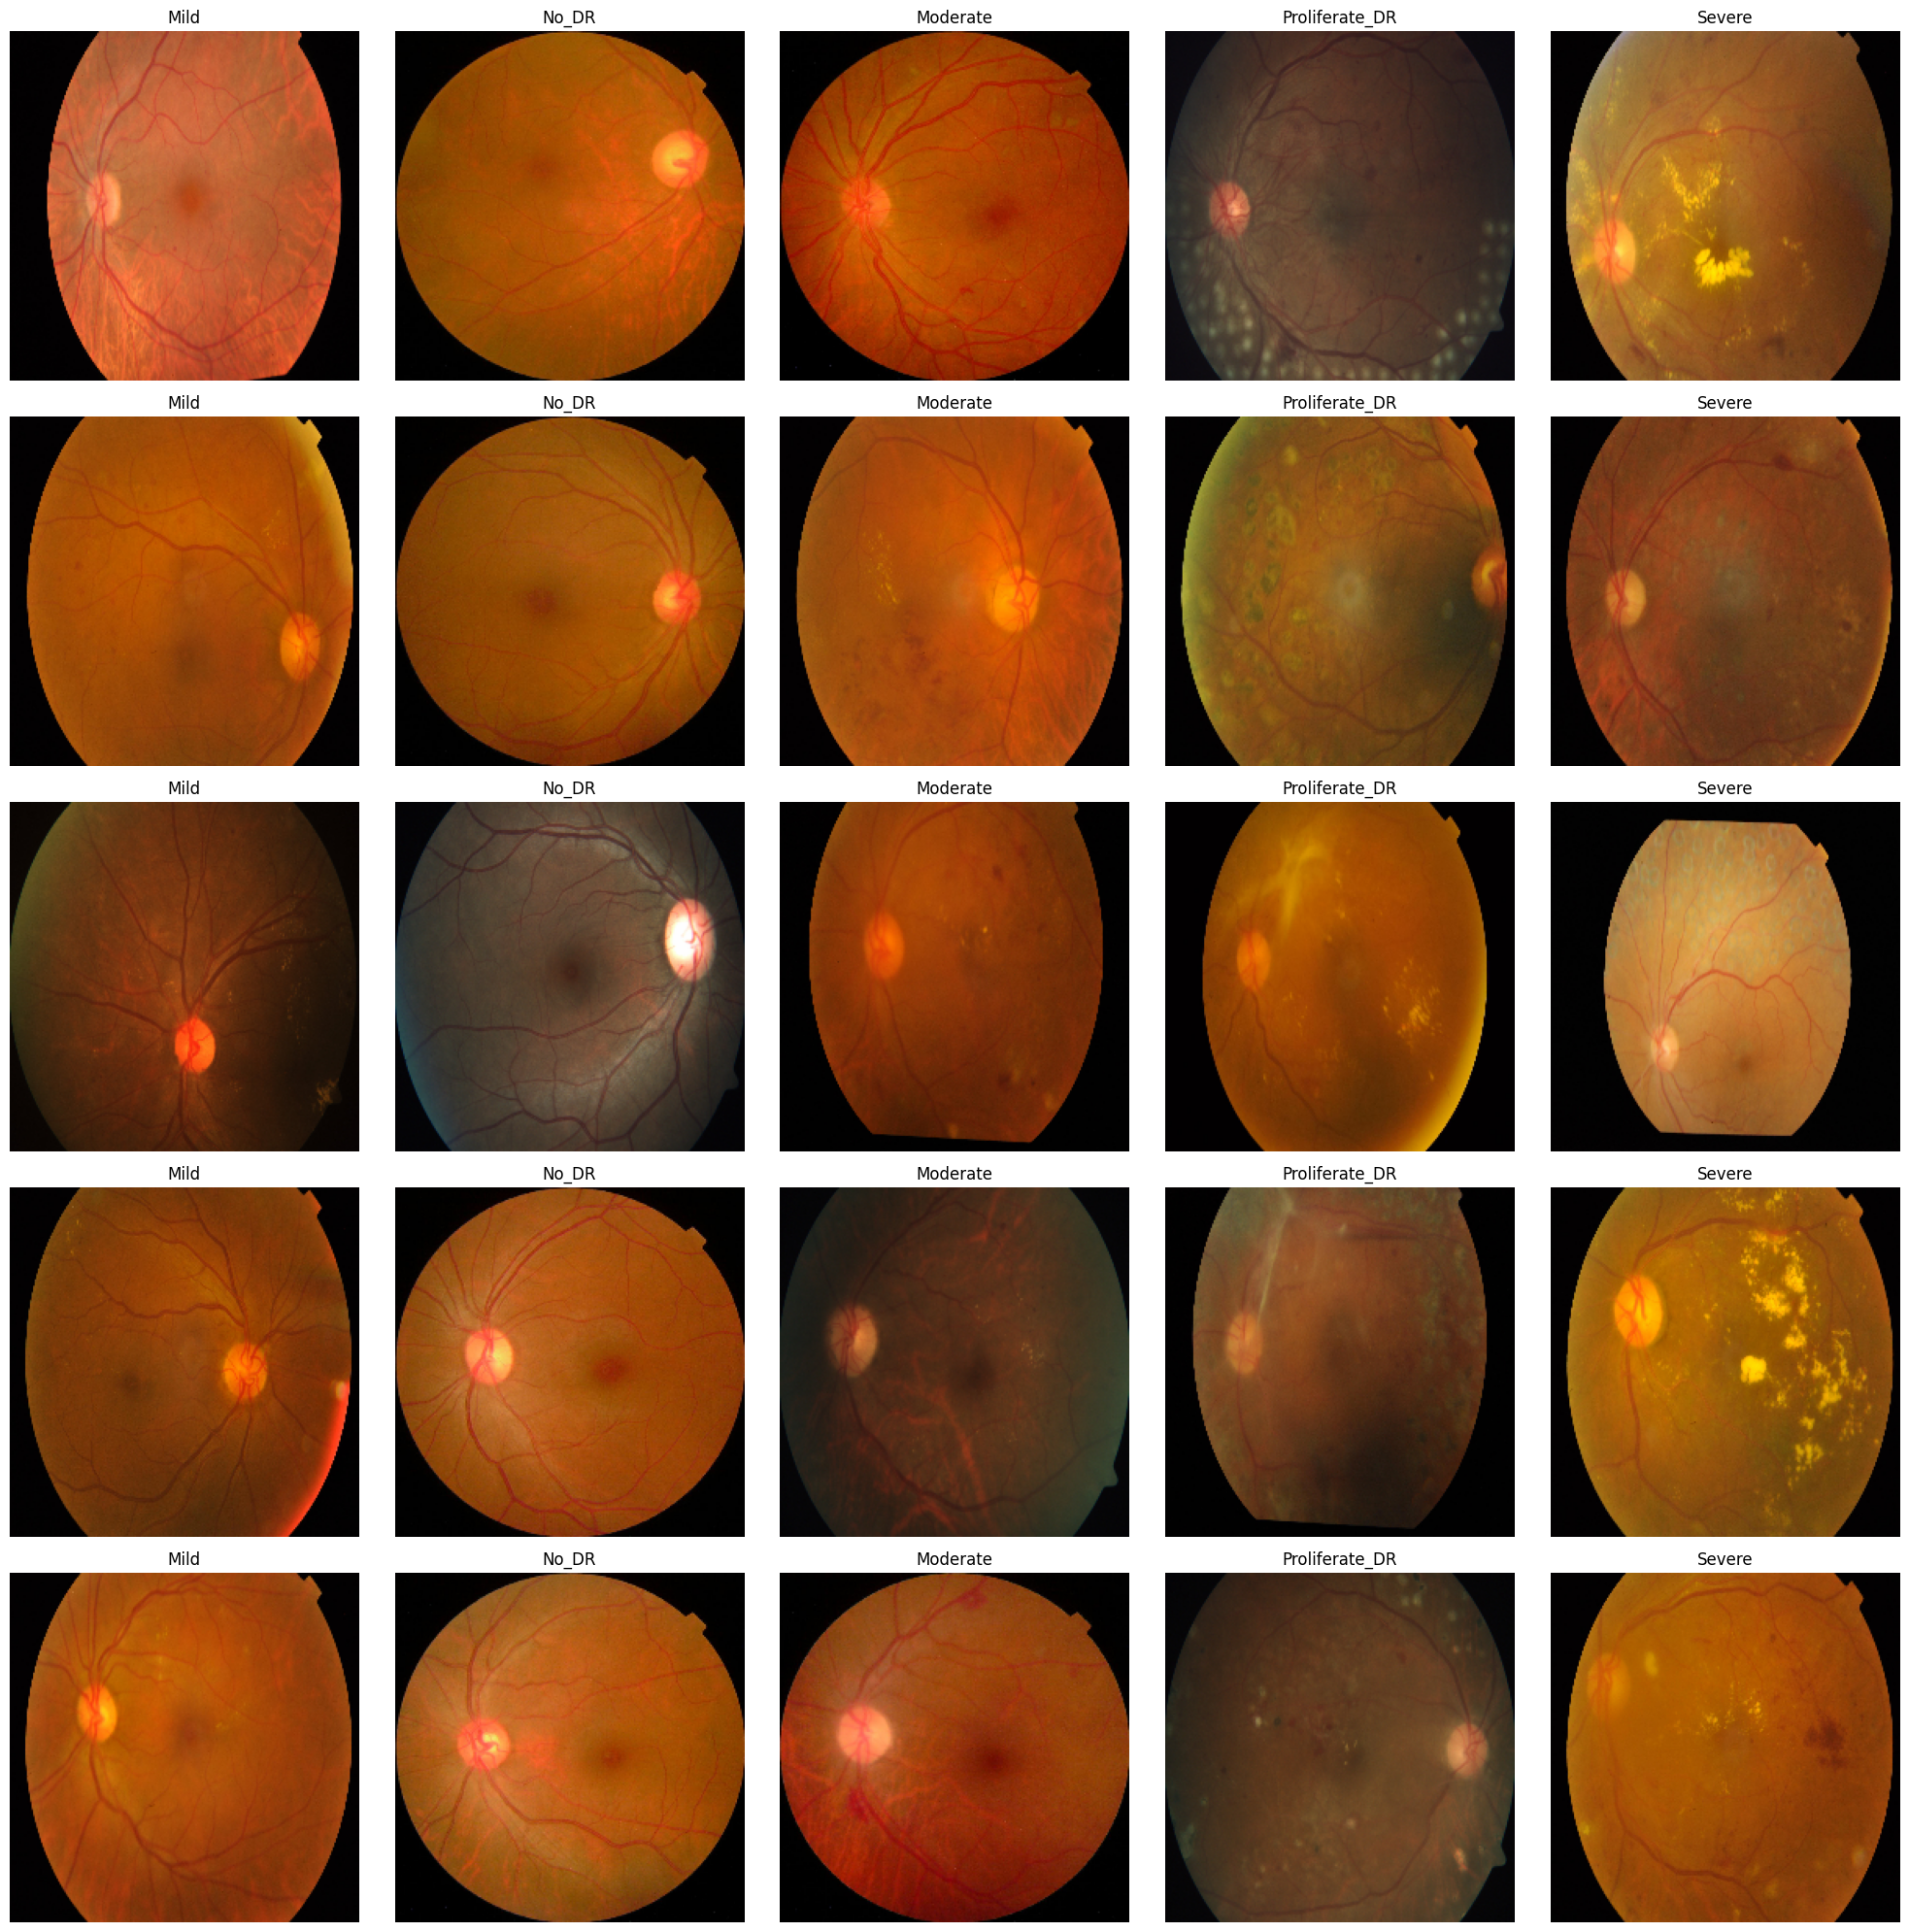

In [5]:
import PIL.Image

# Create a 5x5 grid for displaying 25 images
fig, axs = plt.subplots(5, 5, figsize=(20, 20))
count = 0

# Iterate through each class in the base_path directory
for i, class_name in enumerate(os.listdir(base_path)):
    # Get the list of images in the current class
    class_path = os.path.join(base_path, class_name)

    if os.path.isdir(class_path):  # Ensure it's a directory (class)
        train_class = os.listdir(class_path)

        # Plot 5 images per class
        for j in range(5):
            img_path = os.path.join(class_path, train_class[j])
            img = PIL.Image.open(img_path)

            # Display the image in the subplot and set the title
            axs[j, count].imshow(img)
            axs[j, count].title.set_text(class_name)
            axs[j, count].axis('off')  # Turn off axis for better visuals

        count += 1

# Adjust layout to avoid overlap
fig.tight_layout()
plt.show()


In [6]:
import PIL.Image
import os

# First, check how many images need resizing
need_resize = 0
print("\nChecking which images need resizing...")

for i in os.listdir(base_path):
    train_class = os.listdir(os.path.join(base_path, i))
    print(f"\nClass: {i}")
    class_resize = 0

    for j in train_class:
        img_path = os.path.join(base_path, i, j)

        # Use a try-except block to handle potential errors
        try:
            img = PIL.Image.open(img_path)

            # Check if image needs resizing
            if img.size != (224, 224):
                need_resize += 1
                class_resize += 1
                print(f"Image {j} - Current size: {img.size}")
        except PIL.UnidentifiedImageError:
            print(f"Skipping corrupted image: {img_path}")
            # You might want to remove the corrupted image:
            # os.remove(img_path)
            continue  # Move to the next image

    print(f"Images needing resize in {i} class: {class_resize}")

print(f"\nTotal images that need to be resized: {need_resize}")

# Ask user if they want to proceed with resizing
if need_resize > 0:
    resize_choice = input("\nDo you want to proceed with resizing these images? (yes/no): ")

    if resize_choice.lower() == 'yes':
        # Perform the resizing
        count = 0
        for i in os.listdir(base_path):
            train_class = os.listdir(os.path.join(base_path, i))
            for j in train_class:
                img_path = os.path.join(base_path, i, j)

                # Use a try-except block for resizing as well
                try:
                    img = PIL.Image.open(img_path)
                    if img.size != (224, 224):
                        count += 1
                        resized_img = img.resize((224, 224), PIL.Image.Resampling.LANCZOS)
                        resized_img.save(img_path)
                        print(f"Resized {j} to 224x224 ({count}/{need_resize})")
                except PIL.UnidentifiedImageError:
                    print(f"Skipping corrupted image during resize: {img_path}")
                    os.remove(img_path)
                    continue

        print(f"\nResizing complete! All {need_resize} images have been resized to 224x224")
    else:
        print("\nResizing operation cancelled")
else:
    print("All images are already 224x224! No resizing needed.")


Checking which images need resizing...

Class: Mild
Images needing resize in Mild class: 0

Class: No_DR
Images needing resize in No_DR class: 0

Class: Moderate
Images needing resize in Moderate class: 0

Class: Proliferate_DR
Images needing resize in Proliferate_DR class: 0

Class: Severe
Images needing resize in Severe class: 0

Total images that need to be resized: 0
All images are already 224x224! No resizing needed.


In [7]:
count = 0
for i in os.listdir(base_path):
    train_class = os.listdir(os.path.join(base_path, i))
    for j in train_class:
        img_path = os.path.join(base_path, i, j)

        try:
            img = Image.open(img_path)
            img_array = np.array(img)

            # Normalize pixel values to [0, 1]
            img_array = img_array / 255.0

            # saving the re-scaled image
            img_rescaled = Image.fromarray((img_array * 255).astype(np.uint8))  # Convert back to 0-255 range for saving
            img_rescaled.save(img_path)
            count += 1
        except UnidentifiedImageError:
            print(f"Skipping corrupted image: {img_path}")
            os.remove(img_path)

print(f"\nRescaling complete! {count} images have been rescaled to [0, 1].")


Rescaling complete! 3662 images have been rescaled to [0, 1].


In [8]:
import os
import cv2
from tqdm import tqdm

base_path = "/content/drive/MyDrive/Diabetic_Retinopathy/archive/colored_images"
denoised_path = "/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised"

os.makedirs(denoised_path, exist_ok=True)

count_denoised = 0
# Denoising images
for i in os.listdir(base_path):
    path = os.path.join(base_path, i)
    denoised_path_i = os.path.join(denoised_path, i)

    os.makedirs(denoised_path_i, exist_ok=True)  # Create subfolder
    if not os.path.isdir(path):
        continue  # Skip if not a folder

    for j in tqdm(os.listdir(path), desc=f"Denoising {i}"):
        img_path = os.path.join(path, j)
        denoised_img_path = os.path.join(denoised_path_i, j)
        try:
            # Convert to OpenCV format for denoising
            img_cv = cv2.imread(img_path)

            # Apply Gaussian Blur (Denoising)
            denoised_img = cv2.GaussianBlur(img_cv, (5, 5), 0)

            # Save denoised image to a new folder
            cv2.imwrite(denoised_img_path, denoised_img)
            count_denoised += 1

        except Exception as e:
            print(f"Error denoising {img_path}: {e}")

print(f"\n ✅ Denoising Complete! {count_denoised} images saved to '{denoised_path}'.")

Denoising Severe: 100%|██████████| 193/193 [00:48<00:00,  3.94it/s]


 ✅ Denoising Complete! 3662 images saved to '/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised'.


In [9]:
train = []
label = []

# Iterate through each class folder
for i in os.listdir(denoised_path):
    class_path = os.path.join(denoised_path, i)  # Create full path

    # Check if it's a valid directory
    if os.path.isdir(class_path):
        train_class = os.listdir(class_path)  # List all images in the class folder

        # Debugging: Print number of files found in each category
        print(f"Class '{i}' contains {len(train_class)} images.")

        for j in train_class:
            img = os.path.join(class_path, j)  # Full path to image
            train.append(img)
            label.append(i)

print("\nTotal Number of Train Images:", len(train))

Class 'Mild' contains 370 images.
Class 'No_DR' contains 1805 images.
Class 'Moderate' contains 999 images.
Class 'Proliferate_DR' contains 295 images.
Class 'Severe' contains 193 images.

Total Number of Train Images: 3662


In [10]:
print("\n".join(train))

/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised/Mild/0124dffecf29.png
/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised/Mild/07a1c7073982.png
/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised/Mild/01b3aed3ed4c.png
/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised/Mild/0a3202889f4d.png
/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised/Mild/0ad7f631dedb.png
/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised/Mild/0dc031c94225.png
/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised/Mild/05a5183c92d0.png
/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised/Mild/04ac765f91a1.png
/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised/Mild/09935d72892b.png
/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised/Mild/07929d32b5b3.png
/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised/Mild/06843

In [11]:
print("\n".join(label))

Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild
Mild


In [12]:
# check the number of images in each class in the training dataset

No_images_per_class = []
Class_name = []

for i in os.listdir(denoised_path):
  train_class = os.listdir(os.path.join(denoised_path, i))
  No_images_per_class.append(len(train_class))
  Class_name.append(i)
  print('Number of images in {} = {} \n'.format(i, len(train_class)))

Number of images in Mild = 370 

Number of images in No_DR = 1805 

Number of images in Moderate = 999 

Number of images in Proliferate_DR = 295 

Number of images in Severe = 193 



In [13]:
retina_df = pd.DataFrame({'Image': train,'Labels': label})
retina_df

,Image,Labels
0,/content/drive/MyDrive/Diabetic_Retinopathy/pr...,Mild
1,/content/drive/MyDrive/Diabetic_Retinopathy/pr...,Mild
2,/content/drive/MyDrive/Diabetic_Retinopathy/pr...,Mild
3,/content/drive/MyDrive/Diabetic_Retinopathy/pr...,Mild
4,/content/drive/MyDrive/Diabetic_Retinopathy/pr...,Mild
...,...,...
3657,/content/drive/MyDrive/Diabetic_Retinopathy/pr...,Severe
3658,/content/drive/MyDrive/Diabetic_Retinopathy/pr...,Severe
3659,/content/drive/MyDrive/Diabetic_Retinopathy/pr...,Severe
3660,/content/drive/MyDrive/Diabetic_Retinopathy/pr...,Severe


# PERFORM DATA AUGMENTATION AND CREATE DATA GENERATOR

In [14]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load ResNet50 with pre-trained weights
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze initial layers
for layer in base_model.layers[:140]:  # Fine-tune last few layers
    layer.trainable = False

# Add custom layers on top of ResNet-50
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output_layer = Dense(5, activation="softmax")(x)  # Ensure proper connection

# Create final model
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Model summary
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,769,413 (94.49 MB)

 Trainable params: 16,159,749 (61.64 MB)

 Non-trainable params: 8,609,664 (32.84 MB)

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Rescaling, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.applications import ResNet50

# Define image size and batch size
image_size = (224, 224)
batch_size = 32

# Define data augmentation for training
train_datagen = ImageDataGenerator(

    shear_range=0.2,         # Applies random shearing transformations
    zoom_range=0.2,          # Randomly zooms images up to 20%
    horizontal_flip=True,    # Randomly flips images horizontally
    rotation_range=30,       # Rotates images randomly up to 30 degrees
    width_shift_range=0.2,   # Randomly shifts images horizontally
    height_shift_range=0.2,  # Randomly shifts images vertically
    validation_split=0.15    # Reserves 15% of data for validation
)

# Define data generator for testing
test_datagen = ImageDataGenerator()

# Load training data (80% of the images)
train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised",  # Path to denoised images with 5 class folders
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"  # Training split (80%)
)

# Load validation data (15% of the images)
val_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised",  # Same directory but with validation subset
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"  # Validation split (15%)
)

# Load test data (no split, 5% of data is left for testing)
test_generator = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised",  # Path to test data
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",  # Multi-class classification
    shuffle=False  # Don't shuffle for evaluation
)

# Define the model (Example: ResNet50 as a base model)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the base model

# Create a Sequential model
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dense(5, activation='softmax')  # Assuming 5 classes for Diabetic Retinopathy classification
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
checkpoint = ModelCheckpoint("resnet50_best_model.h5", monitor="val_accuracy", save_best_only=True, mode="max")
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,  # Adjust epochs based on performance
    callbacks=[checkpoint, early_stop]
)

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Found 3116 images belonging to 5 classes.
Found 546 images belonging to 5 classes.
Found 3662 images belonging to 5 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.4919 - loss: 35.0089

98/98 ━━━━━━━━━━━━━━━━━━━━ 88s 745ms/step - accuracy: 0.4929 - loss: 34.7894 - val_accuracy: 0.6337 - val_loss: 0.9023
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.6776 - loss: 0.8795

98/98 ━━━━━━━━━━━━━━━━━━━━ 68s 691ms/step - accuracy: 0.6778 - loss: 0.8795 - val_accuracy: 0.7051 - val_loss: 0.8729
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 60s 609ms/step - accuracy: 0.7283 - loss: 0.8262 - val_accuracy: 0.7015 - val_loss: 0.8225
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.7132 - loss: 0.8070

98/98 ━━━━━━━━━━━━━━━━━━━━ 71s 729ms/step - accuracy: 0.7134 - loss: 0.8066 - val_accuracy: 0.7399 - val_loss: 0.7087
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 58s 593ms/step - accuracy: 0.7318 - loss: 0.7360 - val_accuracy: 0.7289 - val_loss: 0.7419
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 58s 592ms/step - accuracy: 0.7463 - loss: 0.7026 - val_accuracy: 0.7308 - val_loss: 0.7090
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.7478 - loss: 0.6976

98/98 ━━━━━━━━━━━━━━━━━━━━ 67s 685ms/step - accuracy: 0.7478 - loss: 0.6975 - val_accuracy: 0.7509 - val_loss: 0.6789
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 63s 606ms/step - accuracy: 0.7589 - loss: 0.6625 - val_accuracy: 0.7491 - val_loss: 0.6511
Epoch 9/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 76s 586ms/step - accuracy: 0.7341 - loss: 0.6969 - val_accuracy: 0.7509 - val_loss: 0.7120
Epoch 10/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 83s 593ms/step - accuracy: 0.7367 - loss: 0.6928 - val_accuracy: 0.7491 - val_loss: 0.6693
Epoch 11/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.7556 - loss: 0.6174

98/98 ━━━━━━━━━━━━━━━━━━━━ 70s 715ms/step - accuracy: 0.7557 - loss: 0.6174 - val_accuracy: 0.7619 - val_loss: 0.6468
Epoch 12/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 58s 597ms/step - accuracy: 0.7597 - loss: 0.6407 - val_accuracy: 0.7473 - val_loss: 0.6595
Epoch 13/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.7782 - loss: 0.5844

98/98 ━━━━━━━━━━━━━━━━━━━━ 69s 699ms/step - accuracy: 0.7782 - loss: 0.5844 - val_accuracy: 0.7692 - val_loss: 0.6165
Epoch 14/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 57s 586ms/step - accuracy: 0.7887 - loss: 0.5710 - val_accuracy: 0.7656 - val_loss: 0.6439
Epoch 15/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 60s 608ms/step - accuracy: 0.7932 - loss: 0.5838 - val_accuracy: 0.7582 - val_loss: 0.6288
Epoch 16/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.7900 - loss: 0.5765

98/98 ━━━━━━━━━━━━━━━━━━━━ 70s 717ms/step - accuracy: 0.7900 - loss: 0.5765 - val_accuracy: 0.7949 - val_loss: 0.5603
Epoch 17/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 60s 613ms/step - accuracy: 0.7807 - loss: 0.5915 - val_accuracy: 0.7711 - val_loss: 0.6150
Epoch 18/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 80s 595ms/step - accuracy: 0.7817 - loss: 0.5698 - val_accuracy: 0.7582 - val_loss: 0.6378
Epoch 19/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 59s 600ms/step - accuracy: 0.8038 - loss: 0.5402 - val_accuracy: 0.7527 - val_loss: 0.6058
Epoch 20/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 59s 599ms/step - accuracy: 0.7927 - loss: 0.5381 - val_accuracy: 0.7527 - val_loss: 0.6625
115/115 ━━━━━━━━━━━━━━━━━━━━ 21s 186ms/step - accuracy: 0.7835 - loss: 0.6263
Test Accuracy: 81.81%


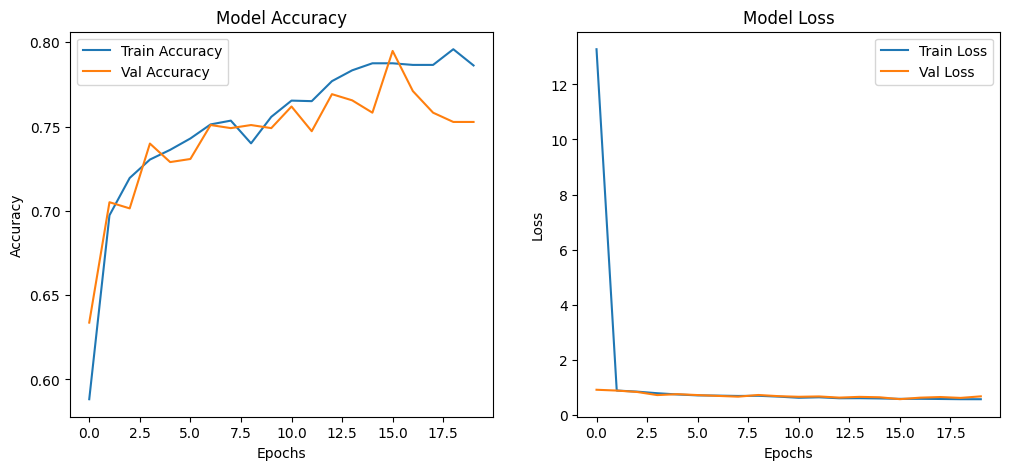

In [16]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Loss")
plt.show()


In [17]:
from tensorflow.keras.models import load_model
import numpy as np
from tensorflow.keras.preprocessing import image

# Load the best saved model
model = load_model("resnet50_best_model.h5")

# Define the class labels (ensure these match the labels used in your training)
class_labels = {
    0: 'Mild',    # Replace with actual class names
    1: 'Proliferate_DR',
    2: 'Severe',
    3:  'No_DR',
    4: 'Moderate'
}

# Function to predict a single image
def predict_image(img_path):
    # Load the image and resize to match model's input shape
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)  # Convert image to numpy array
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalize image

    # Predict class
    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction)  # Get the predicted class index

    # Output the predicted class label and confidence
    print(f"Predicted Class: {class_labels[class_idx]} (Confidence: {np.max(prediction)*100:.2f}%)")

# Example usage (Make sure to replace with an actual image file path)
predict_image("/content/drive/MyDrive/Diabetic_Retinopathy/processed_images/denoised/Severe/c68dfa021d62.png")


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predicted Class: Severe (Confidence: 99.95%)
